Libraries

In [84]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

Load data

In [85]:
# Reload original dataset from CSV
df = pd.read_csv("thyroidDF.csv")

# Now inspect the REAL target labels
print(df['target'].unique())
print(df['target'].value_counts())

['-' 'S' 'F' 'AK' 'R' 'I' 'M' 'N' 'G' 'K' 'A' 'KJ' 'L' 'MK' 'Q' 'J' 'C|I'
 'O' 'LJ' 'H|K' 'D' 'GK' 'MI' 'P' 'FK' 'B' 'GI' 'C' 'GKJ' 'OI' 'D|R' 'E']
target
-      6771
K       436
G       359
I       346
F       233
R       196
A       147
L       115
M       111
N       110
S        85
GK       49
AK       46
J        30
B        21
MK       16
O        14
Q        14
C|I      12
KJ       11
GI       10
H|K       8
D         8
FK        6
C         6
P         5
MI        2
LJ        1
GKJ       1
OI        1
D|R       1
E         1
Name: count, dtype: int64


Basic Data Preprocessing

In [86]:
print(df.isnull().sum()[df.isnull().sum() > 0])
df.replace("?", np.nan, inplace=True)
df.replace("", np.nan, inplace=True)
df.replace({'t': 1, 'f': 0}, inplace=True)

# Drop patient_id if present
if 'patient_id' in df.columns:
    df.drop(columns=['patient_id'], inplace=True)

numeric_cols = ['age','TSH','T3','TT4','T4U','FTI','TBG']

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(df['target'].unique())

df = df[df['age'] < 120]
df['sex'] = df['sex'].fillna('Unknown')

df['target'] = df['target'].astype(str).str.strip()
df['target'] = df['target'].replace('-', 'negative')
df['target'] = df['target'].apply(lambda x: 0 if x == 'negative' else 1)

print(df['target'].value_counts())


sex     307
TSH     842
T3     2604
TT4     442
T4U     809
FTI     802
TBG    8823
dtype: int64
['-' 'S' 'F' 'AK' 'R' 'I' 'M' 'N' 'G' 'K' 'A' 'KJ' 'L' 'MK' 'Q' 'J' 'C|I'
 'O' 'LJ' 'H|K' 'D' 'GK' 'MI' 'P' 'FK' 'B' 'GI' 'C' 'GKJ' 'OI' 'D|R' 'E']
target
0    6767
1    2401
Name: count, dtype: int64


C:\Users\HS TRADER\AppData\Local\Temp\ipykernel_10708\3034071295.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({'t': 1, 'f': 0}, inplace=True)


Visualization – Target Distribution

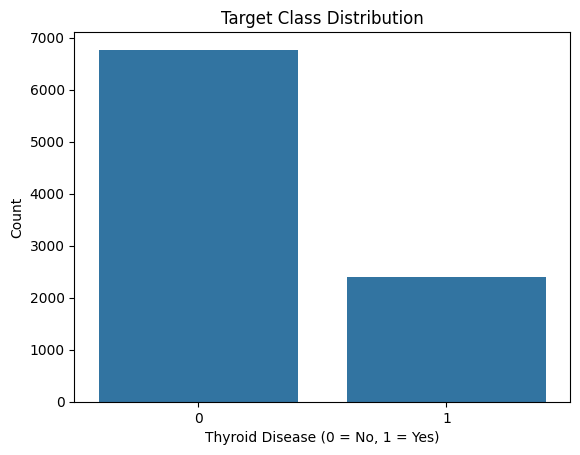

In [87]:
sns.countplot(x='target', data=df)
plt.title("Target Class Distribution")
plt.xlabel("Thyroid Disease (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

Feature–Target Split

In [88]:

X = df.drop('target', axis=1)
y = df['target']


Train–Test Split

In [89]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [90]:
print("Full dataset target distribution:")
print(df['target'].value_counts())

print("\nTraining set target distribution:")
print(y_train.value_counts())

print("\nTest set target distribution:")
print(y_test.value_counts())

Full dataset target distribution:
target
0    6767
1    2401
Name: count, dtype: int64

Training set target distribution:
target
0    5413
1    1921
Name: count, dtype: int64

Test set target distribution:
target
0    1354
1     480
Name: count, dtype: int64


Identify Numerical & Categorical Columns

In [91]:
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

print("Numeric Columns:", list(numeric_features))
print("Categorical Columns:", list(categorical_features))

Numeric Columns: ['age', 'on_thyroxine', 'query_on_thyroxine', 'on_antithyroid_meds', 'sick', 'pregnant', 'thyroid_surgery', 'I131_treatment', 'query_hypothyroid', 'query_hyperthyroid', 'lithium', 'goitre', 'tumor', 'hypopituitary', 'psych', 'TSH_measured', 'TSH', 'T3_measured', 'T3', 'TT4_measured', 'TT4', 'T4U_measured', 'T4U', 'FTI_measured', 'FTI', 'TBG_measured', 'TBG']
Categorical Columns: ['sex', 'referral_source']


Train the Model

In [92]:
from sklearn.impute import SimpleImputer

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')) #Fills missing numeric values
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore')) #converts categorical to 0/1
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', 
RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=42
))
])


xgb_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    ))
])

# Train XGBoost
xgb_model.fit(X_train, y_train)


model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


Predictions

In [93]:
y_pred = model.predict(X_test)
xgb_pred = xgb_model.predict(X_test)

Feature Importance

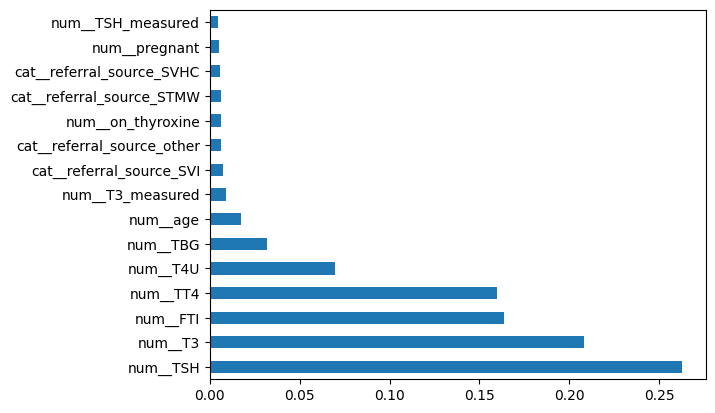

In [94]:
feature_names = model.named_steps['preprocessor'].get_feature_names_out()
importances = model.named_steps['classifier'].feature_importances_

feat_imp = pd.Series(importances, index=feature_names)
feat_imp.nlargest(15).plot(kind='barh')
plt.show()

Save Model

In [95]:
import joblib
joblib.dump(model, "thyroid_model.pkl")
joblib.dump(xgb_model, "xgb_model.pkl")

['xgb_model.pkl']

Better Metric (Imbalanced Data)

In [96]:

from sklearn.metrics import roc_auc_score
print("ROC AUC:", roc_auc_score(y_test, model.predict_proba(X_test)[:,1]))
print("XGB ROC AUC:", roc_auc_score(y_test, xgb_model.predict_proba(X_test)[:,1]))

ROC AUC: 0.9910035081240767
XGB ROC AUC: 0.9934622722796653


Model Evaluation

In [97]:
# Predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Accuracy
print("Train Accuracy:", accuracy_score(y_train, y_train_pred))
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))

# Classification report
print("\nClassification Report:\n", classification_report(y_test, y_test_pred))

Train Accuracy: 0.9802290700845377
Test Accuracy: 0.955288985823337

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.96      0.97      1354
           1       0.90      0.94      0.92       480

    accuracy                           0.96      1834
   macro avg       0.94      0.95      0.94      1834
weighted avg       0.96      0.96      0.96      1834



Confusion Matrix (Visualization)

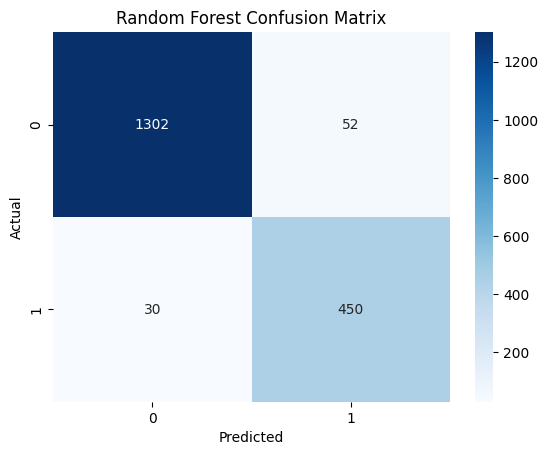

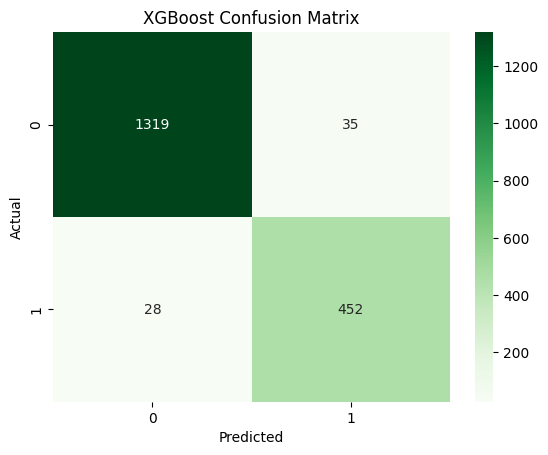

In [98]:
# ✅ Random Forest CM
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ✅ XGBoost CM
cm_xgb = confusion_matrix(y_test, xgb_pred)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Greens')
plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Implementation / demo values

In [99]:
# Create demo patient
new_patient = pd.DataFrame([{
    **X[numeric_features].mean().to_dict(),
    **X[categorical_features].mode().iloc[0].to_dict()
}])[X.columns]

# ✅ Random Forest Prediction
rf_pred = model.predict(new_patient)[0]

# ✅ XGBoost Prediction
xgb_pred = xgb_model.predict(new_patient)[0]

# ✅ Show both results
print("\nRandom Forest Prediction:",
      "Disease" if rf_pred == 1 else "Normal")

print("XGBoost Prediction:",
      "Disease" if xgb_pred == 1 else "Normal")



Random Forest Prediction: Normal
XGBoost Prediction: Normal


Taking User Input to predict

In [101]:
# ==========================================
# Take Patient Data from User and Predict
# ==========================================

# Take inputs from user
age = int(input("Enter Age: "))
sex = input("Enter Sex (M/F): ").strip().upper()

on_thyroxine = int(input("On Thyroxine? (1=yes, 0=no): "))
query_on_thyroxine = int(input("Query on Thyroxine? (1=yes, 0=no): "))
on_antithyroid_meds = int(input("On Antithyroid Medication? (1=yes, 0=no): "))
sick = int(input("Sick? (1=yes, 0=no): "))
pregnant = int(input("Pregnant? (1=yes, 0=no): "))
thyroid_surgery = int(input("Thyroid Surgery? (1=yes, 0=no): "))
I131_treatment = int(input("I131 Treatment? (1=yes, 0=no): "))
query_hypothyroid = int(input("Query Hypothyroid? (1=yes, 0=no): "))
query_hyperthyroid = int(input("Query Hyperthyroid? (1=yes, 0=no): "))
lithium = int(input("Lithium? (1=yes, 0=no): "))
goitre = int(input("Goitre? (1=yes, 0=no): "))
tumor = int(input("Tumor? (1=yes, 0=no): "))
hypopituitary = int(input("Hypopituitary? (1=yes, 0=no): "))
psych = int(input("Psych? (1=yes, 0=no): "))

TSH_measured = int(input("TSH Measured? (1=yes, 0=no): "))
TSH_input = input("TSH Value: ").strip()
try:
    TSH = float(TSH_input) if TSH_input != "" else np.nan
except ValueError:
    TSH = np.nan

T3_measured = int(input("T3 Measured? (1=yes, 0=no): "))
if T3_measured == 1:
    T3_input = input("T3 Value: ").strip()
    try:
        T3 = float(T3_input) if T3_input != "" else np.nan
    except ValueError:
        T3 = np.nan
else:
    T3 = np.nan

TT4_measured = int(input("TT4 Measured? (1=yes, 0=no): "))
if TT4_measured == 1:
    TT4_input = input("TT4 Value: ").strip()
    try:
        TT4 = float(TT4_input) if TT4_input != "" else np.nan
    except ValueError:
        TT4 = np.nan
else:
    TT4 = np.nan

T4U_measured = int(input("T4U Measured? (1=yes, 0=no): "))
if T4U_measured == 1:
    T4U_input = input("T4U Value: ").strip()
    try:
        T4U = float(T4U_input) if T4U_input != "" else np.nan
    except ValueError:
        T4U = np.nan
else:
    T4U = np.nan

FTI_measured = int(input("FTI Measured? (1=yes, 0=no): "))
if FTI_measured == 1:
    FTI_input = input("FTI Value: ").strip()
    try:
        FTI = float(FTI_input) if FTI_input != "" else np.nan
    except ValueError:
        FTI = np.nan
else:
    FTI = np.nan

TBG_measured = int(input("TBG Measured? (1=yes, 0=no): "))
if TBG_measured == 1:
    TBG_input = input("TBG Value: ").strip()
    try:
        TBG = float(TBG_input) if TBG_input != "" else np.nan
    except ValueError:
        TBG = np.nan
else:
    TBG = np.nan

referral_source = input("Referral Source (e.g., SVHC, SVI, STMW): ").strip().upper()

# Create DataFrame
new_patient = pd.DataFrame([{
    'age': age,
    'sex': sex,
    'on_thyroxine': on_thyroxine,
    'query_on_thyroxine': query_on_thyroxine,
    'on_antithyroid_meds': on_antithyroid_meds,
    'sick': sick,
    'pregnant': pregnant,
    'thyroid_surgery': thyroid_surgery,
    'I131_treatment': I131_treatment,
    'query_hypothyroid': query_hypothyroid,
    'query_hyperthyroid': query_hyperthyroid,
    'lithium': lithium,
    'goitre': goitre,
    'tumor': tumor,
    'hypopituitary': hypopituitary,
    'psych': psych,
    'TSH_measured': TSH_measured,
    'TSH': TSH,
    'T3_measured': T3_measured,
    'T3': T3,
    'TT4_measured': TT4_measured,
    'TT4': TT4,
    'T4U_measured': T4U_measured,
    'T4U': T4U,
    'FTI_measured': FTI_measured,
    'FTI': FTI,
    'TBG_measured': TBG_measured,
    'TBG': TBG,
    'referral_source': referral_source
}])

#predict
# Random Forest
rf_pred = model.predict(new_patient)[0]
rf_prob = model.predict_proba(new_patient)[0][1]

# XGBoost
xgb_pred = xgb_model.predict(new_patient)[0]
xgb_prob = xgb_model.predict_proba(new_patient)[0][1]

# Show results
print("\n===== Prediction Result =====")

print("\n--- Random Forest ---")
if rf_pred == 1:
    print("Thyroid Disease Detected")
else:
    print("No Thyroid Disease Detected")
print(f"Probability: {rf_prob * 100:.2f}%")

print("\n--- XGBoost ---")
if xgb_pred == 1:
    print("Thyroid Disease Detected")
else:
    print("No Thyroid Disease Detected")
print(f"Probability: {xgb_prob * 100:.2f}%")


===== Prediction Result =====

--- Random Forest ---
No Thyroid Disease Detected
Probability: 12.52%

--- XGBoost ---
No Thyroid Disease Detected
Probability: 0.87%
